# Agriculture Telemetry Analysis Dashboard\n\nAnalyzes `agriculture.db`: soil moisture/temp trends, anomalies, device stats.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
conn = sqlite3.connect('agriculture.db')
df = pd.read_sql_query('SELECT * FROM telemetry_logs ORDER BY timestamp', conn)
conn.close()
print(f'Loaded {len(df)} records')
df.head()

Loaded 2577 records


,id,timestamp,level,device_id,moisture,temperature,humidity,status_message
0,1,2026-04-07 13:03:52,INFO,SOIL_S2,32.11,21.36,NaN,"Moisture: 32.11%, Temp: 21.36C | Status: OK"
1,2,2026-04-07 13:03:52,INFO,WEATHER_W1,NaN,27.92,47.31,"Temp: 27.92C, Humidity: 47.31% | Status: OK"
2,3,2026-04-07 13:03:52,INFO,PUMP_P1,NaN,NaN,NaN,Pump Status: ACTIVE | Feedback: SUCCESS
3,4,2026-04-07 13:09:52,INFO,SOIL_S1,44.62,24.03,NaN,"Moisture: 44.62%, Temp: 24.03C | Status: OK"
4,5,2026-04-07 13:09:52,INFO,SOIL_S2,45.35,20.02,NaN,"Moisture: 45.35%, Temp: 20.02C | Status: OK"


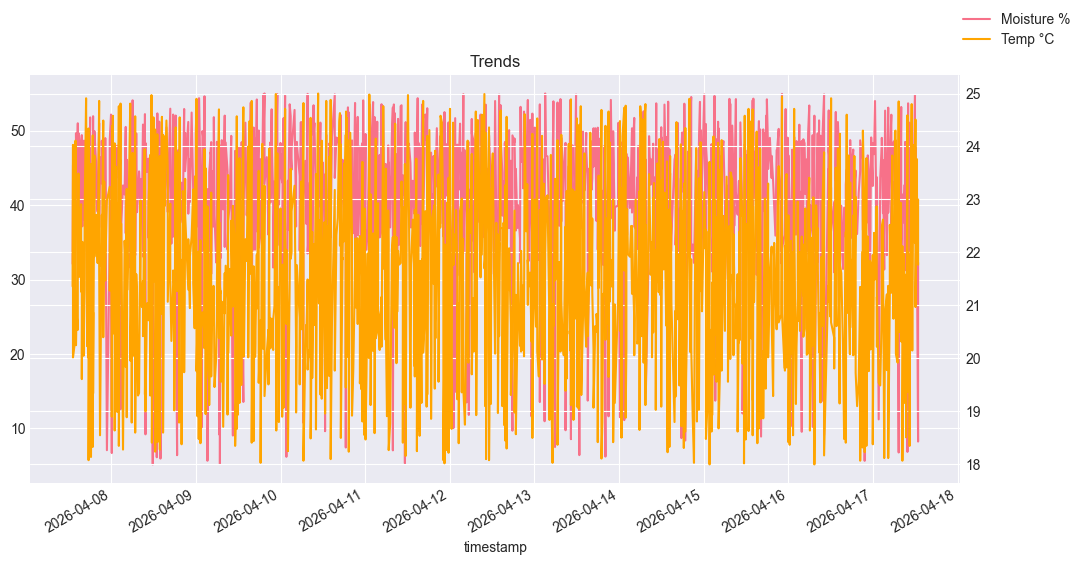

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df_plot = df.dropna(subset=['moisture','temperature']).set_index('timestamp')

fig, ax = plt.subplots(figsize=(12,6))
df_plot['moisture'].plot(ax=ax, label='Moisture %')
ax_twin = ax.twinx()
df_plot['temperature'].plot(ax=ax_twin, label='Temp °C', color='orange')
plt.title('Trends')
fig.legend(loc='upper right')
plt.show()

anomaly
False    2505
True       72
Name: count, dtype: int64


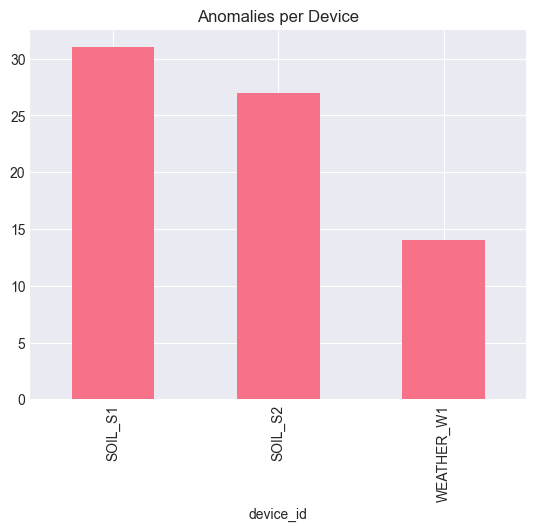

In [4]:
# Anomalies\n
df['anomaly'] = (df['level'] != 'INFO') | (df['moisture'] < 20) | (df['temperature'] > 40)
print(df['anomaly'].value_counts())

anoms = df[df['anomaly'] == True].groupby('device_id').size()
anoms.plot(kind='bar', title='Anomalies per Device')
plt.show()

            moisture  temperature  anomaly_count
device_id                                       
PUMP_P1          NaN          NaN              0
SOIL_S1        43.38        22.43             31
SOIL_S2        38.79        20.48             27
WEATHER_W1       NaN        25.48             14


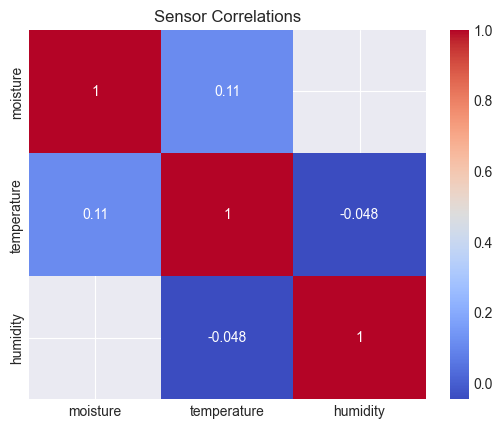

In [6]:
# Device stats (numeric only)\n
stats = df.groupby('device_id')[['moisture', 'temperature']].mean().round(2)
stats['anomaly_count'] = df[df['level'] != 'INFO'].groupby('device_id').size().reindex(stats.index, fill_value=0)
print(stats)

# Correlation (numeric only)\n
corr_data = df[['moisture','temperature','humidity']].select_dtypes(include=['number']).corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm')
plt.title('Sensor Correlations')
plt.show()